# 03 — Spectrogram EDA

Visual EDA: random sample of control vs PD spectrograms; mean spectrogram
per group; difference map. Builds intuition for what (if any) features
will be discriminative before any model is trained.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 4)

import random
from src.data_loader import DATA_ROOT, iter_trials, load_trial
from src import radar_params as P

random.seed(0)


## 1. Random sample — 4 controls × 4 PD, foot channel

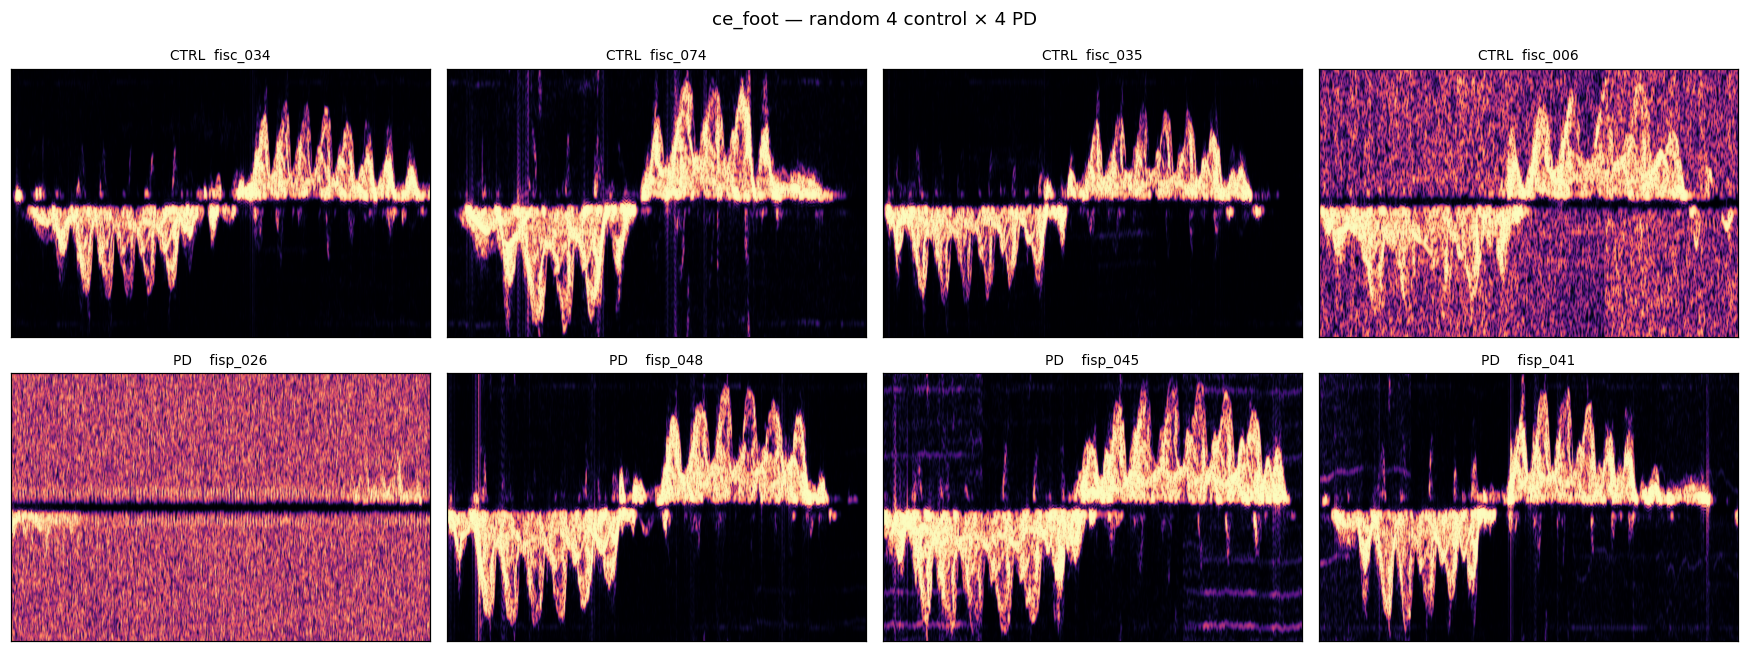

In [2]:
trials = list(iter_trials())
controls = [t for t in trials if t.group == "control"]
pd_trials = [t for t in trials if t.group == "pd"]

sample_ctrl = random.sample(controls, 4)
sample_pd = random.sample(pd_trials, 4)

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=False, sharey=True)
for col, tp in enumerate(sample_ctrl):
    trial = load_trial(tp.path)
    axes[0, col].imshow(np.log1p(trial["ce_foot"]), aspect="auto",
                        origin="lower", cmap="magma")
    axes[0, col].set_title(f"CTRL  {tp.subject_id}", fontsize=9)
for col, tp in enumerate(sample_pd):
    trial = load_trial(tp.path)
    axes[1, col].imshow(np.log1p(trial["ce_foot"]), aspect="auto",
                        origin="lower", cmap="magma")
    axes[1, col].set_title(f"PD    {tp.subject_id}", fontsize=9)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("ce_foot — random 4 control × 4 PD")
plt.tight_layout(); plt.show()


## 2. Same subject, three trials

How stable is one subject's spectrogram across repeated trials?

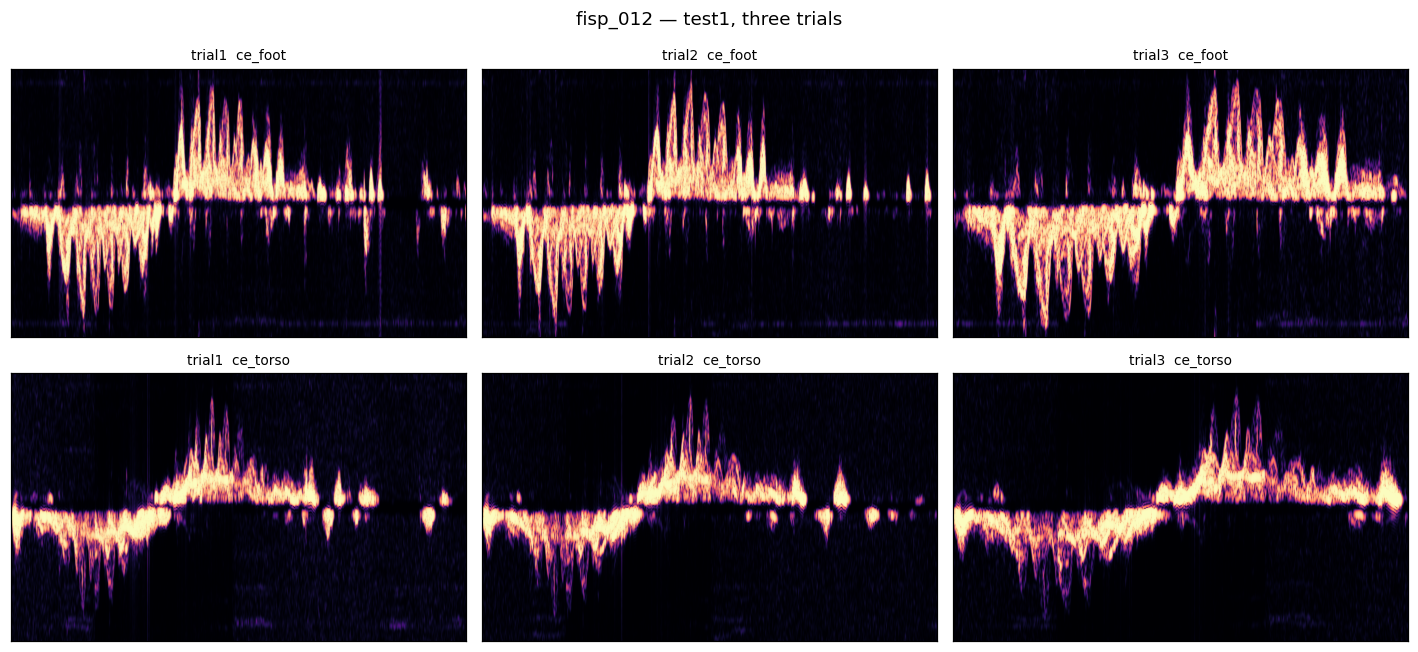

In [3]:
subj = "fisp_012"
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True)
for col, trial_name in enumerate(["trial1", "trial2", "trial3"]):
    trial = load_trial(DATA_ROOT / subj / "test1" / trial_name / "stft_data.mat")
    axes[0, col].imshow(np.log1p(trial["ce_foot"]), aspect="auto", origin="lower", cmap="magma")
    axes[0, col].set_title(f"{trial_name}  ce_foot", fontsize=9)
    axes[1, col].imshow(np.log1p(trial["ce_torso"]), aspect="auto", origin="lower", cmap="magma")
    axes[1, col].set_title(f"{trial_name}  ce_torso", fontsize=9)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{subj} — test1, three trials")
plt.tight_layout(); plt.show()


## 3. test1 vs test2 — protocol difference

test1 = TUG with chair; test2 = TUG without chair (stand-start).

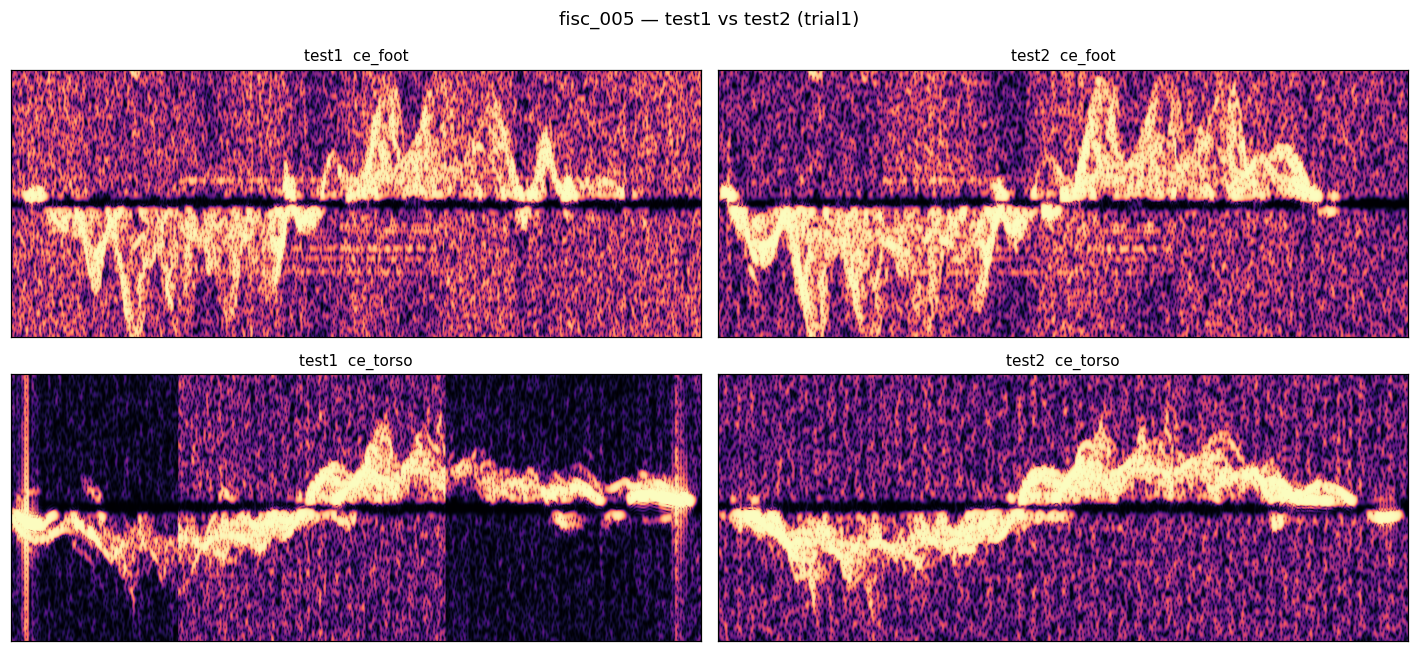

In [4]:
subj = "fisc_005"
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharey=True)
for col, test_name in enumerate(["test1", "test2"]):
    trial = load_trial(DATA_ROOT / subj / test_name / "trial1" / "stft_data.mat")
    axes[0, col].imshow(np.log1p(trial["ce_foot"]), aspect="auto", origin="lower", cmap="magma")
    axes[0, col].set_title(f"{test_name}  ce_foot", fontsize=10)
    axes[1, col].imshow(np.log1p(trial["ce_torso"]), aspect="auto", origin="lower", cmap="magma")
    axes[1, col].set_title(f"{test_name}  ce_torso", fontsize=10)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{subj} — test1 vs test2 (trial1)")
plt.tight_layout(); plt.show()


## 4. Mean spectrogram per group

Resize every spectrogram to a fixed shape, then average. The result hides
within-subject variability but reveals systematic group-level differences.

Loading every trial is slow (~5 min). The first cell builds the means; the
second plots them. Set `LIMIT` lower for a quick first pass.


In [5]:
from tqdm.auto import tqdm
from src.preprocessing import resize_2d

TARGET_SHAPE = (128, 256)  # (doppler, time)
LIMIT = 20                 # trials per group; bump to None for full pass

def mean_spectrogram(trial_paths, key, target):
    acc = np.zeros(target, dtype=np.float64)
    n = 0
    for tp in tqdm(trial_paths, desc=key):
        try:
            tr = load_trial(tp.path)
            spec = np.log1p(tr[key])
            acc += resize_2d(spec, target)
            n += 1
        except Exception:
            continue
    return acc / max(n, 1), n

ctrl_paths = random.sample(controls, min(LIMIT, len(controls)))
pd_paths = random.sample(pd_trials, min(LIMIT, len(pd_trials)))

mean_ctrl_foot, n_ctrl = mean_spectrogram(ctrl_paths, "ce_foot", TARGET_SHAPE)
mean_pd_foot, n_pd = mean_spectrogram(pd_paths, "ce_foot", TARGET_SHAPE)
print(f"averaged {n_ctrl} control and {n_pd} PD trials")


ce_foot:   0%|          | 0/20 [00:00<?, ?it/s]

ce_foot:   0%|          | 0/20 [00:00<?, ?it/s]

averaged 20 control and 20 PD trials


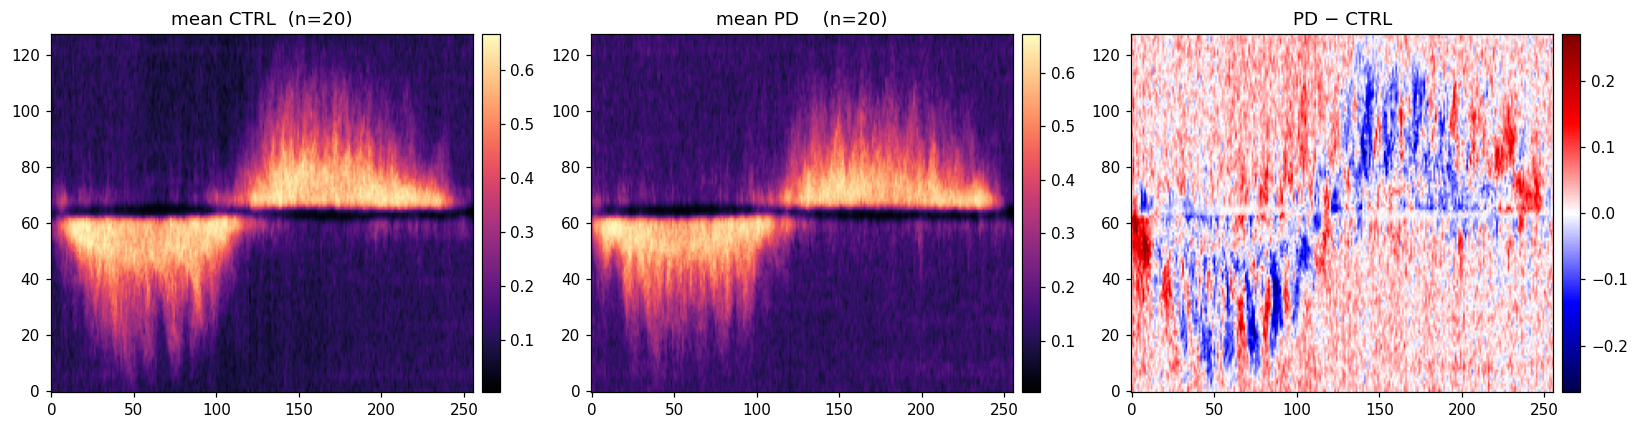

In [6]:
diff = mean_pd_foot - mean_ctrl_foot

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, title, cmap in [
    (axes[0], mean_ctrl_foot, f"mean CTRL  (n={n_ctrl})", "magma"),
    (axes[1], mean_pd_foot,   f"mean PD    (n={n_pd})",   "magma"),
    (axes[2], diff,           "PD − CTRL",                "seismic"),
]:
    vmax = np.abs(img).max() if cmap == "seismic" else None
    im = ax.imshow(img, aspect="auto", origin="lower", cmap=cmap,
                   vmin=-vmax if vmax else None, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()


### Reading the difference map

- **Red bands** = PD has more energy than controls at those (Doppler, time) positions.
- **Blue bands** = controls have more.

Clinical intuition: PD gait often shows *reduced* foot Doppler peaks (smaller toe-clearance, shorter strides), so we expect blue at high Doppler and red at low Doppler if the effect is visible at the population level. If you don't see anything systematic in a 20-vs-20 sample, that's also informative: any signal will need a real classifier to extract.
